<a href="https://colab.research.google.com/github/Fearless2389/Human-Annotator-Analysis/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Human Annotator Disagreement (CIFAR-10H)
## Deep Neural Networks — Course Project

This notebook predicts the full human annotator label distribution for CIFAR-10 images
using a CIFAR-adapted ResNet-18, treating disagreement as signal rather than noise.

In [ ]:

from google.colab import drive
drive.mount('/content/drive')
import sys; sys.path.append('/content/drive/MyDrive/DNN_Project')

from utils import *
print(f'Device: {device}')

Mounted at /content/drive
Device: cuda


---
# Section 1: Data Pipeline

In [ ]:
# Load everything
data = load_data()
cifar10_train = data['cifar10_train']
cifar10_test  = data['cifar10_test']
soft_labels   = data['soft_labels']
hard_labels   = data['hard_labels']
train_idx     = data['train_idx']
val_idx       = data['val_idx']
test_idx      = data['test_idx']
entropies     = data['entropies']

100%|██████████| 170M/170M [00:08<00:00, 19.8MB/s]


CIFAR-10 train: 50000 | CIFAR-10H: 10000
Splits — Train: 6000, Val: 2000, Test: 2000


In [ ]:
# Sanity checks
sums = soft_labels.sum(axis=1)
print(f'Soft label sums — min: {sums.min():.6f}, max: {sums.max():.6f}')
assert np.allclose(sums, 1.0, atol=1e-5), 'Some soft labels do not sum to 1!'

high_agree = soft_labels.max(axis=1) > 0.9
agree_rate = (soft_labels[high_agree].argmax(1) == hard_labels[high_agree]).mean()
print(f'High-agreement alignment: {agree_rate:.4f}')
print(f'Entropy — mean: {entropies.mean():.4f}, std: {entropies.std():.4f}, '
      f'range: [{entropies.min():.4f}, {entropies.max():.4f}]')

Soft label sums — min: 1.000000, max: 1.000000
High-agreement alignment: 0.9997
Entropy — mean: 0.2228, std: 0.3395, range: [0.0000, 2.8602]


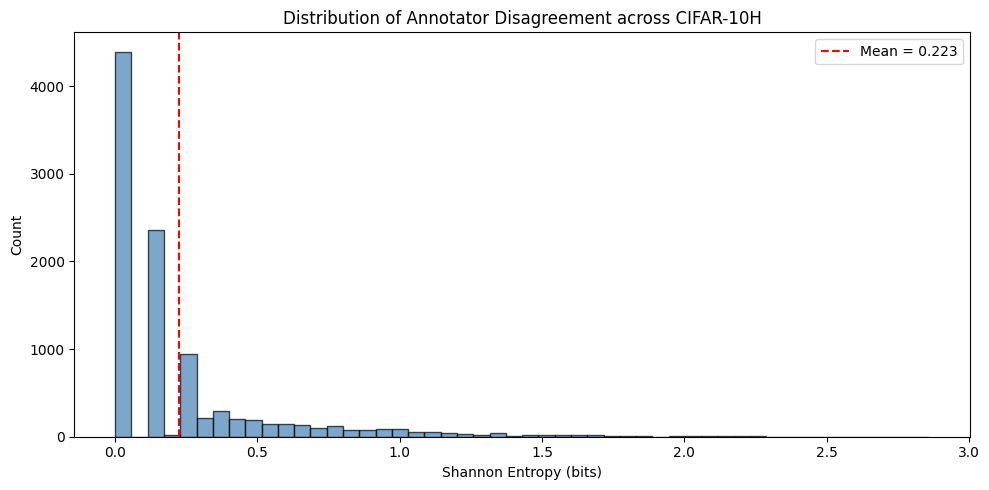

In [ ]:
# Viz 1: Entropy histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(entropies, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(entropies.mean(), color='red', linestyle='--', label=f'Mean = {entropies.mean():.3f}')
ax.set_xlabel('Shannon Entropy (bits)'); ax.set_ylabel('Count')
ax.set_title('Distribution of Annotator Disagreement across CIFAR-10H')
ax.legend(); plt.tight_layout(); plt.savefig('viz_entropy_histogram.png', dpi=150); plt.show()

/tmp/ipykernel_408/540704443.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha='right')


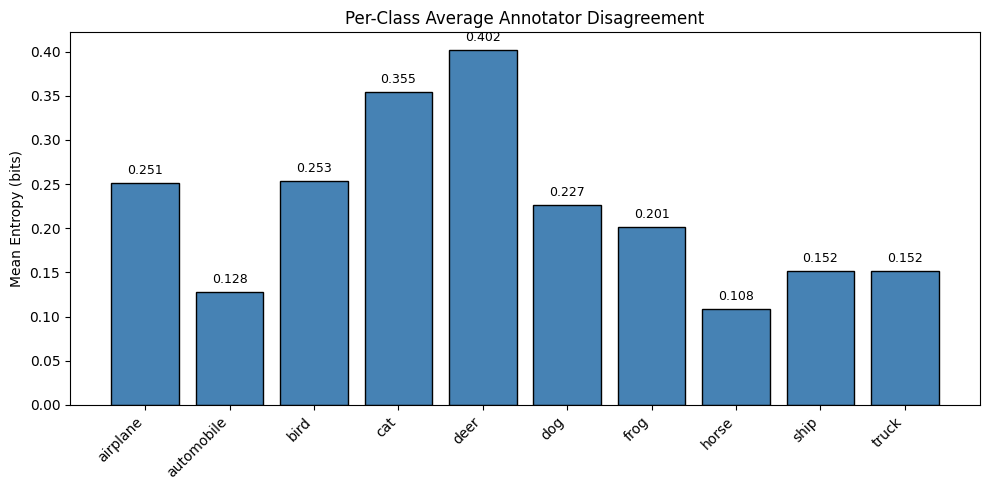

In [ ]:
# Viz 2: Per-class average entropy
class_ent = [entropies[hard_labels == c].mean() for c in range(10)]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(CIFAR10_CLASSES, class_ent, color='steelblue', edgecolor='black')
for b, v in zip(bars, class_ent): ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=9)
ax.set_ylabel('Mean Entropy (bits)'); ax.set_title('Per-Class Average Annotator Disagreement')
ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha='right')
plt.tight_layout(); plt.savefig('viz_per_class_entropy.png', dpi=150); plt.show()

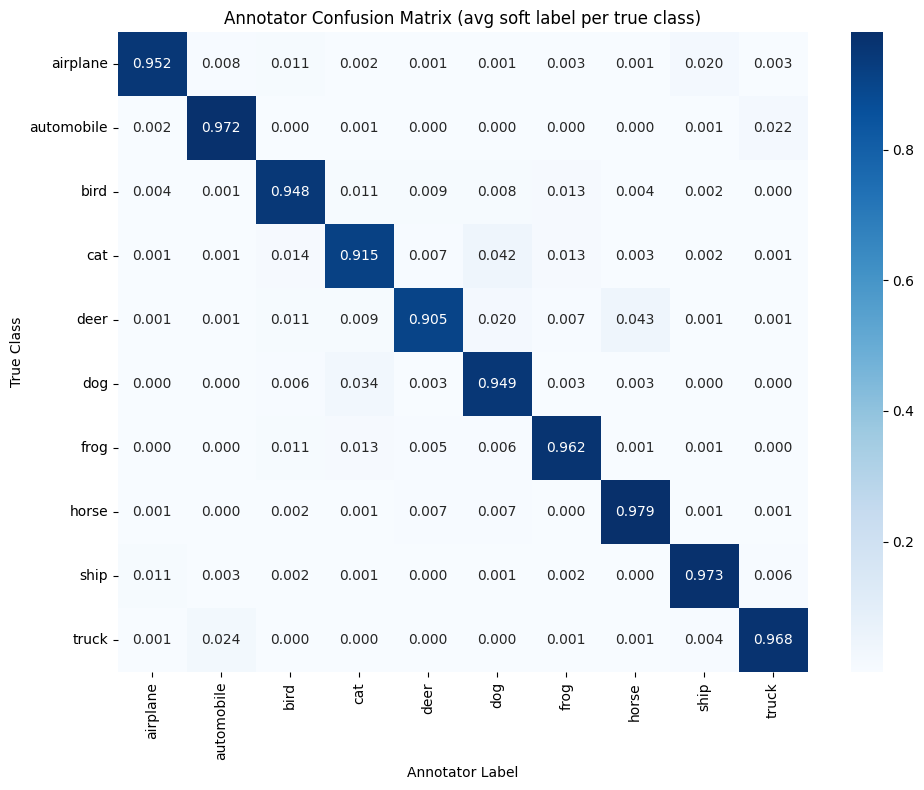

In [ ]:
# Viz 3: Annotator confusion matrix
conf_mat = np.zeros((10, 10))
for c in range(10): conf_mat[c] = soft_labels[hard_labels == c].mean(axis=0)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES, ax=ax)
ax.set_xlabel('Annotator Label'); ax.set_ylabel('True Class')
ax.set_title('Annotator Confusion Matrix (avg soft label per true class)')
plt.tight_layout(); plt.savefig('viz_annotator_confusion.png', dpi=150); plt.show()

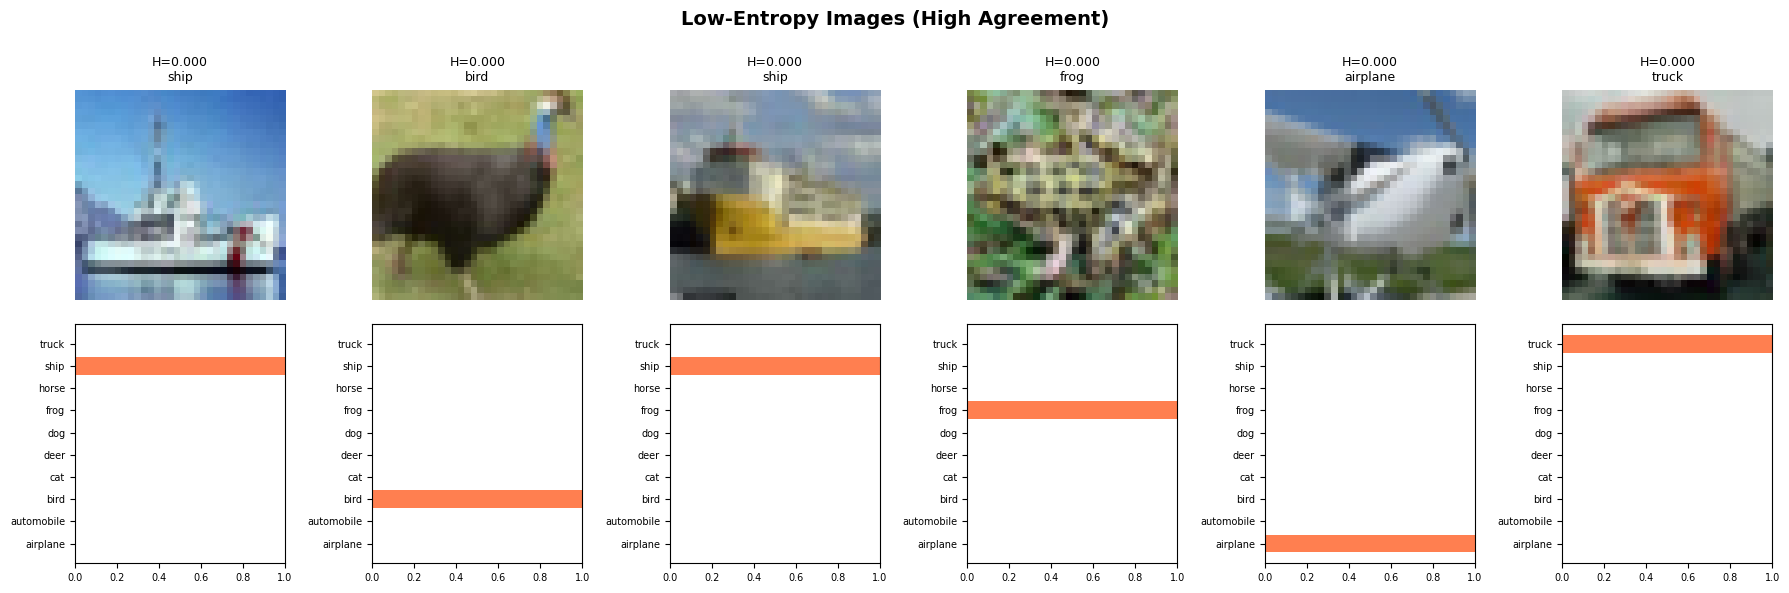

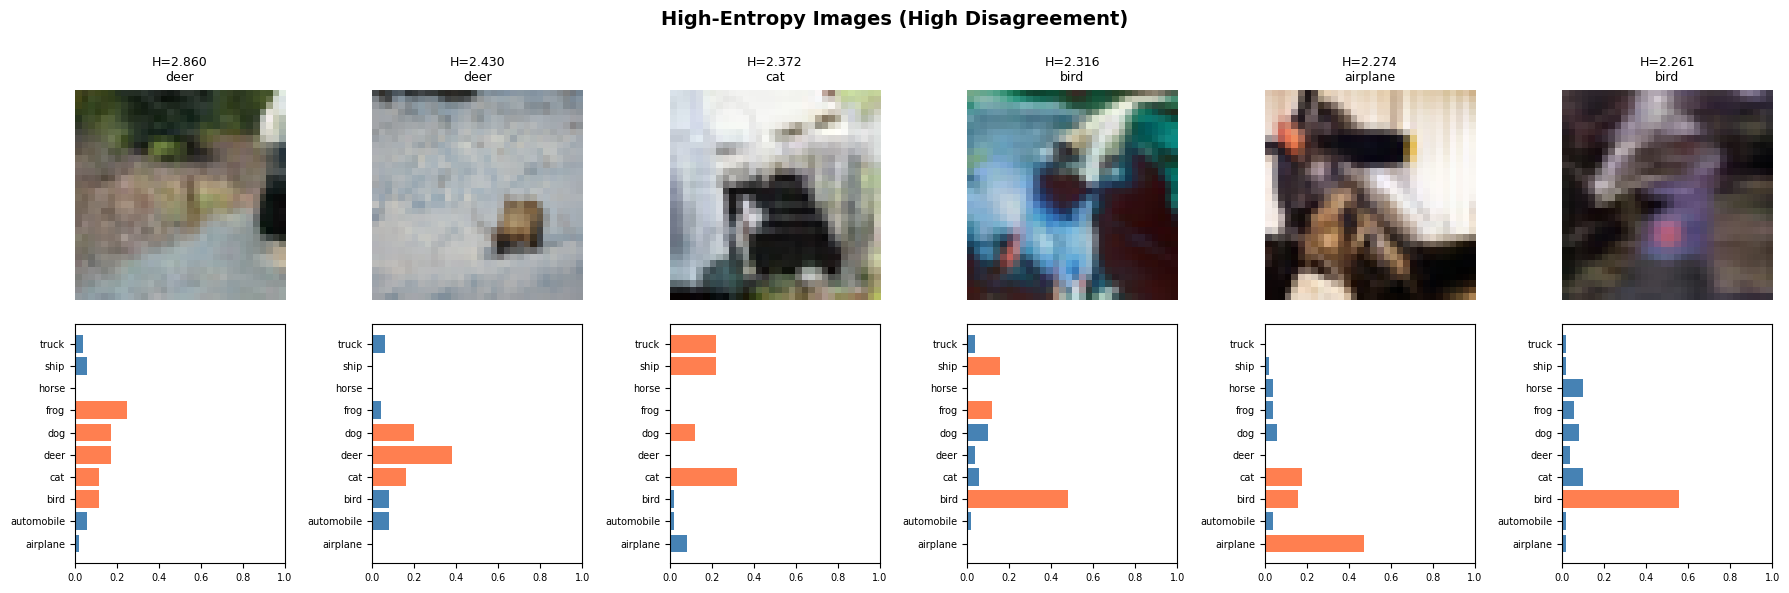

In [ ]:
# Viz 4 & 5: Low and high entropy image grids
sorted_ent = np.argsort(entropies)
show_image_grid(cifar10_test, sorted_ent[:6], soft_labels, entropies, hard_labels,
                'Low-Entropy Images (High Agreement)', 'viz_low_entropy_grid.png')
show_image_grid(cifar10_test, sorted_ent[-6:][::-1], soft_labels, entropies, hard_labels,
                'High-Entropy Images (High Disagreement)', 'viz_high_entropy_grid.png')

---
# Section 2: Model Architecture & Training

In [ ]:
# Architecture summary
model = make_cifar_resnet18()
total_params = sum(p.numel() for p in model.parameters())
print(f'ResNet-18 (CIFAR-adapted) | Params: {total_params:,} | Input: 32x32x3 | Output: 10-dim softmax')
print(f'Conv1: 3x3/stride1 | MaxPool: removed | Head: Linear(512,10) + Softmax')

ResNet-18 (CIFAR-adapted) | Params: 11,173,962 | Input: 32x32x3 | Output: 10-dim softmax
Conv1: 3x3/stride1 | MaxPool: removed | Head: Linear(512,10) + Softmax


In [ ]:
# Create dataloaders
cifar10_train_t = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=train_transform)
cifar10_val_t = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=test_transform)
hard_train_loader = DataLoader(cifar10_train_t, batch_size=128, shuffle=True, num_workers=2)
hard_val_loader = DataLoader(cifar10_val_t, batch_size=128, shuffle=False, num_workers=2)

soft_train_loader = DataLoader(CIFAR10H_Dataset(cifar10_test, soft_labels, train_idx, train_transform),
                               batch_size=128, shuffle=True, num_workers=2)
soft_val_loader = DataLoader(CIFAR10H_Dataset(cifar10_test, soft_labels, val_idx, test_transform),
                             batch_size=128, shuffle=False, num_workers=2)
soft_test_loader = DataLoader(CIFAR10H_Dataset(cifar10_test, soft_labels, test_idx, test_transform),
                              batch_size=128, shuffle=False, num_workers=2)
print('Dataloaders ready.')

Dataloaders ready.


In [ ]:
# Phase 1: Pretrain on hard labels
print('PHASE 1: Pretraining on CIFAR-10 Hard Labels (50 epochs)')
model_pre = make_cifar_resnet18().to(device)
opt_pre = optim.Adam(model_pre.parameters(), lr=1e-3)
sched_pre = optim.lr_scheduler.CosineAnnealingLR(opt_pre, T_max=50)
ce_loss = nn.CrossEntropyLoss()

pre_hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(50):
    tl, ta = train_hard_label_epoch(model_pre, hard_train_loader, ce_loss, opt_pre, device)
    vl, va = eval_hard_label(model_pre, hard_val_loader, ce_loss, device)
    sched_pre.step()
    pre_hist['train_loss'].append(tl); pre_hist['val_loss'].append(vl)
    pre_hist['train_acc'].append(ta); pre_hist['val_acc'].append(va)
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model_pre.state_dict(), os.path.join(SAVE_DIR, 'pretrained_best.pth'))
    if (epoch+1) % 10 == 0:
        print(f'  Epoch {epoch+1}/50 | Train: {tl:.4f} ({ta:.4f}) | Val: {vl:.4f} ({va:.4f})')

print(f'Best val accuracy: {best_val_acc:.4f}')

PHASE 1: Pretraining on CIFAR-10 Hard Labels (50 epochs)
  Epoch 10/50 | Train: 0.2952 (0.8960) | Val: 0.4608 (0.8558)
  Epoch 20/50 | Train: 0.1201 (0.9576) | Val: 0.4513 (0.8824)
  Epoch 30/50 | Train: 0.0364 (0.9876) | Val: 0.3800 (0.9143)
  Epoch 40/50 | Train: 0.0080 (0.9975) | Val: 0.4125 (0.9236)
  Epoch 50/50 | Train: 0.0026 (0.9995) | Val: 0.4094 (0.9273)
Best val accuracy: 0.9285


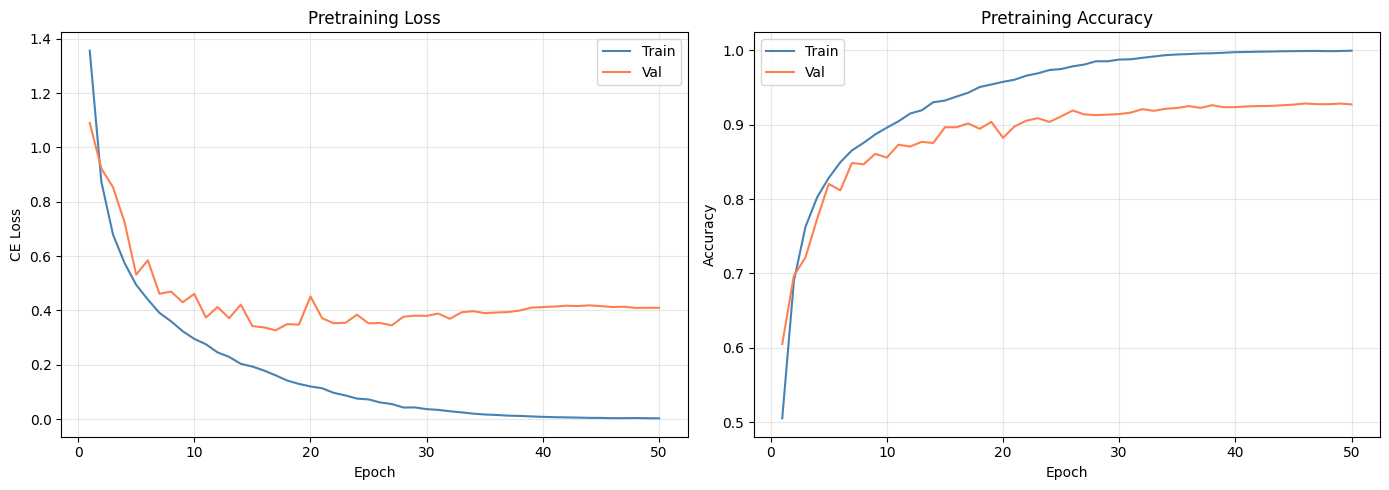

In [ ]:
# Pretraining curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, 51)
ax1.plot(ep, pre_hist['train_loss'], label='Train', color='steelblue')
ax1.plot(ep, pre_hist['val_loss'], label='Val', color='coral')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('CE Loss'); ax1.set_title('Pretraining Loss'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep, pre_hist['train_acc'], label='Train', color='steelblue')
ax2.plot(ep, pre_hist['val_acc'], label='Val', color='coral')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('Pretraining Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('viz_pretrain_curves.png', dpi=150); plt.show()

In [ ]:
# Phase 2: Fine-tune with 3 loss functions
loss_fns = {
    'KL_Divergence': KLDivergenceLoss(),
    'Soft_CrossEntropy': SoftCrossEntropyLoss(),
    'KL_EntropyError': KLPlusEntropyErrorLoss(lambda_entropy=1.0),
}
ft_hist = {}

for name, criterion in loss_fns.items():
    print(f'\nFine-tuning: {name}')
    model = make_cifar_resnet18().to(device)
    model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'pretrained_best.pth'), map_location=device))
    opt = optim.Adam(model.parameters(), lr=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=100)

    hist = {'train_loss': [], 'val_loss': [], 'val_kl': []}
    best_vl, patience = float('inf'), 0

    for epoch in range(100):
        tl = train_soft_label_epoch(model, soft_train_loader, criterion, opt, device)
        vl = eval_soft_label(model, soft_val_loader, criterion, device)
        vkl = compute_val_kl(model, soft_val_loader, device)
        sched.step()
        hist['train_loss'].append(tl); hist['val_loss'].append(vl); hist['val_kl'].append(vkl)

        if vl < best_vl:
            best_vl, patience = vl, 0
            torch.save(model.state_dict(), os.path.join(SAVE_DIR, f'best_{name}.pth'))
        else:
            patience += 1
        if (epoch+1) % 20 == 0:
            print(f'  Epoch {epoch+1} | Train: {tl:.6f} | Val: {vl:.6f} | Val KL: {vkl:.6f}')
        if patience >= 10:
            print(f'  Early stopping at epoch {epoch+1}')
            break
    ft_hist[name] = hist
    print(f'  Best val loss: {best_vl:.6f}')


Fine-tuning: KL_Divergence
  Epoch 20 | Train: 0.159806 | Val: 0.288725 | Val KL: 0.288725
  Epoch 40 | Train: 0.110711 | Val: 0.261458 | Val KL: 0.261458
  Epoch 60 | Train: 0.088715 | Val: 0.255892 | Val KL: 0.255892
  Epoch 80 | Train: 0.080840 | Val: 0.253121 | Val KL: 0.253121
  Early stopping at epoch 85
  Best val loss: 0.252222

Fine-tuning: Soft_CrossEntropy
  Epoch 20 | Train: 0.317530 | Val: 0.443783 | Val KL: 0.293565
  Epoch 40 | Train: 0.262663 | Val: 0.412281 | Val KL: 0.262062
  Epoch 60 | Train: 0.241763 | Val: 0.406517 | Val KL: 0.256299
  Epoch 80 | Train: 0.236108 | Val: 0.403363 | Val KL: 0.253144
  Early stopping at epoch 96
  Best val loss: 0.402109

Fine-tuning: KL_EntropyError
  Epoch 20 | Train: 0.221431 | Val: 0.410365 | Val KL: 0.327919
  Epoch 40 | Train: 0.151732 | Val: 0.385657 | Val KL: 0.295753
  Early stopping at epoch 55
  Best val loss: 0.381163


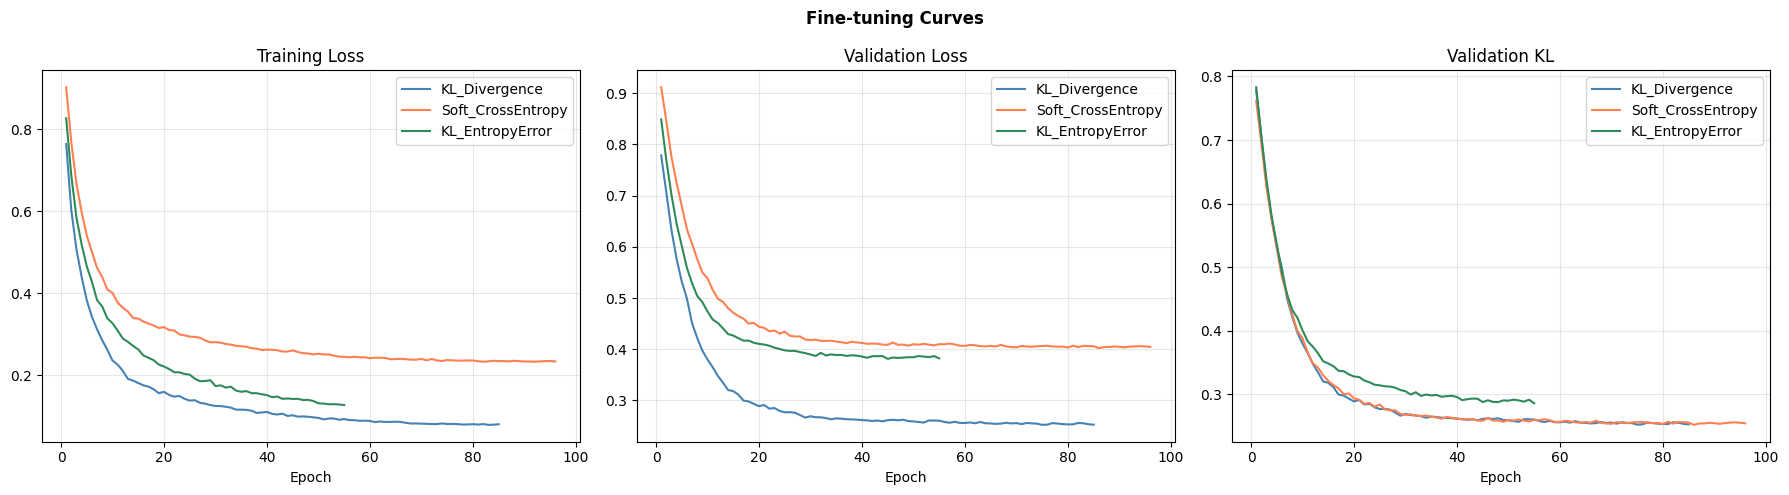

In [ ]:
# Fine-tuning curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'KL_Divergence': 'steelblue', 'Soft_CrossEntropy': 'coral', 'KL_EntropyError': 'seagreen'}
for name, h in ft_hist.items():
    ep = range(1, len(h['train_loss'])+1)
    axes[0].plot(ep, h['train_loss'], label=name, color=colors[name])
    axes[1].plot(ep, h['val_loss'], label=name, color=colors[name])
    axes[2].plot(ep, h['val_kl'], label=name, color=colors[name])
for ax, t in zip(axes, ['Training Loss', 'Validation Loss', 'Validation KL']):
    ax.set_title(t); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Fine-tuning Curves', fontweight='bold')
plt.tight_layout(); plt.savefig('viz_finetune_curves.png', dpi=150); plt.show()

---
# Section 3: Evaluation, Ablations & Robustness

In [ ]:
# Load all 3 models and get predictions
loss_names = ['KL_Divergence', 'Soft_CrossEntropy', 'KL_EntropyError']
predictions = {}
for name in loss_names:
    m = make_cifar_resnet18().to(device)
    m.load_state_dict(torch.load(os.path.join(SAVE_DIR, f'best_{name}.pth'), map_location=device))
    preds, true_soft, true_hard = get_predictions(m, soft_test_loader, device)
    predictions[name] = preds
    print(f'Loaded: {name}')

true_entropy = compute_entropy_np(true_soft)

Loaded: KL_Divergence
Loaded: Soft_CrossEntropy
Loaded: KL_EntropyError


In [ ]:
# Core metrics table
results = {}
for name in loss_names:
    p = predictions[name]
    pe = compute_entropy_np(p)
    kl = compute_kl_per_sample(true_soft, p)
    jsd = compute_jsd_per_sample(true_soft, p)
    cos = compute_cosine_per_sample(true_soft, p)
    pr, _ = pearsonr(true_entropy, pe)
    sr, _ = spearmanr(true_entropy, pe)
    results[name] = {
        'KL': f'{kl.mean():.4f} +/- {kl.std():.4f}',
        'JSD': f'{jsd.mean():.4f} +/- {jsd.std():.4f}',
        'Cosine': f'{cos.mean():.4f} +/- {cos.std():.4f}',
        'Pearson': f'{pr:.4f}', 'Spearman': f'{sr:.4f}',
        'P@100': f'{precision_at_k(true_entropy, pe, 100):.4f}',
        'P@200': f'{precision_at_k(true_entropy, pe, 200):.4f}',
        'P@500': f'{precision_at_k(true_entropy, pe, 500):.4f}',
        '_kl': kl.mean(), '_cos': cos.mean(), '_pr': pr, '_pe': pe,
    }

# Print table
print(f'{"Metric":<20}', '  '.join(f'{n:<22}' for n in loss_names))
print('-'*90)
for metric in ['KL','JSD','Cosine','Pearson','Spearman','P@100','P@200','P@500']:
    print(f'{metric:<20}', '  '.join(f'{results[n][metric]:<22}' for n in loss_names))

Metric               KL_Divergence           Soft_CrossEntropy       KL_EntropyError       
------------------------------------------------------------------------------------------
KL                   0.2732 +/- 0.6594       0.2714 +/- 0.6474       0.3160 +/- 0.7809     
JSD                  0.0515 +/- 0.1134       0.0517 +/- 0.1132       0.0510 +/- 0.1177     
Cosine               0.9338 +/- 0.1952       0.9335 +/- 0.1954       0.9322 +/- 0.2011     
Pearson              0.4532                  0.4458                  0.4217                
Spearman             0.4437                  0.4435                  0.4411                
P@100                0.2200                  0.2200                  0.2100                
P@200                0.3550                  0.3600                  0.3550                
P@500                0.5200                  0.5220                  0.5140                


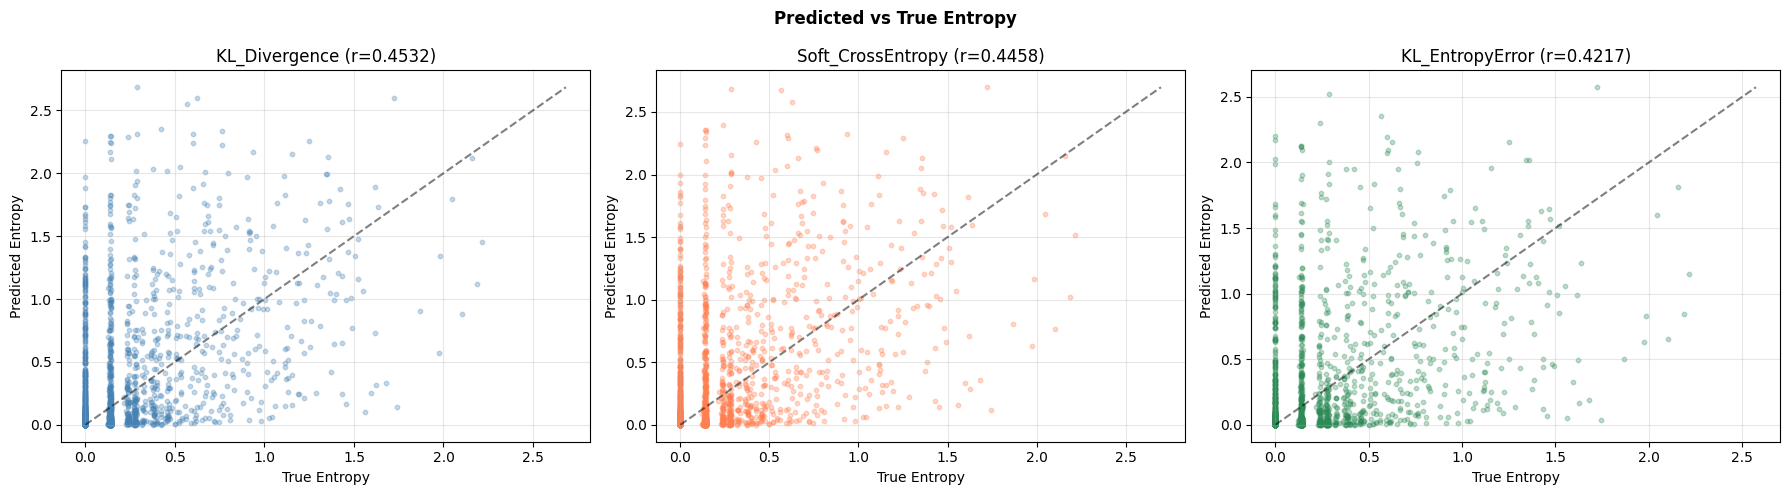

In [ ]:
# Scatter: predicted vs true entropy
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, loss_names):
    pe = results[name]['_pe']
    ax.scatter(true_entropy, pe, alpha=0.3, s=10, c=colors[name])
    mx = max(true_entropy.max(), pe.max())
    ax.plot([0, mx], [0, mx], 'k--', alpha=0.5)
    ax.set_xlabel('True Entropy'); ax.set_ylabel('Predicted Entropy')
    ax.set_title(f'{name} (r={results[name]["_pr"]:.4f})'); ax.grid(alpha=0.3)
plt.suptitle('Predicted vs True Entropy', fontweight='bold')
plt.tight_layout(); plt.savefig('viz_entropy_scatter.png', dpi=150); plt.show()

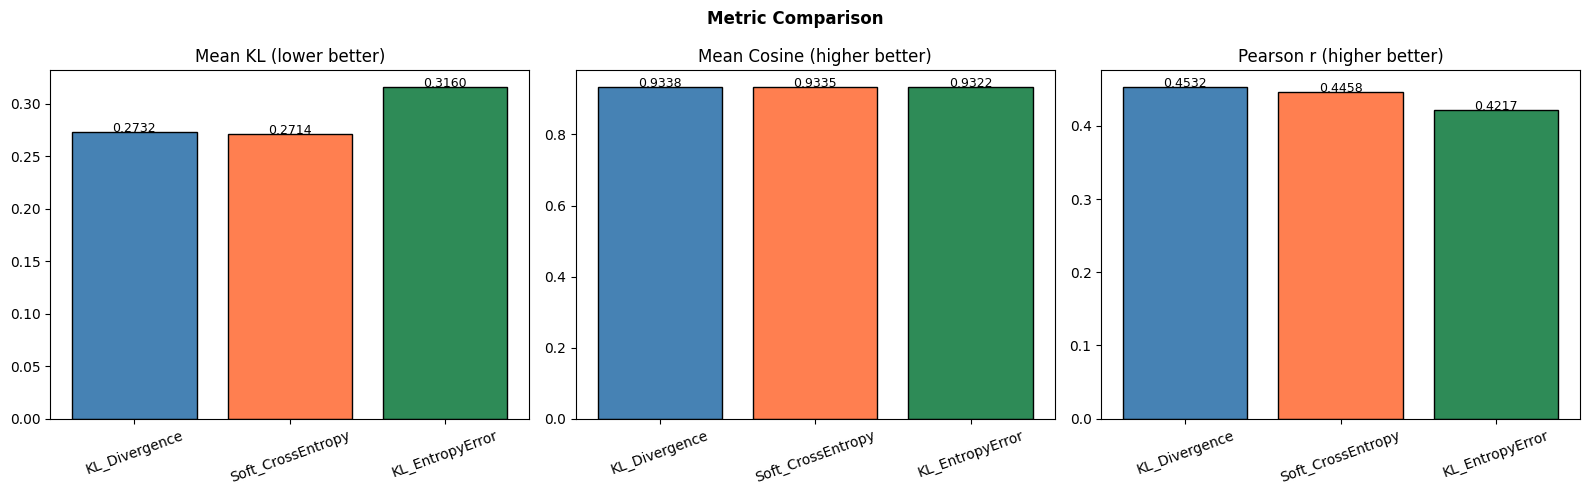

In [ ]:
# Grouped bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, key, title in zip(axes, ['_kl','_cos','_pr'],
    ['Mean KL (lower better)','Mean Cosine (higher better)','Pearson r (higher better)']):
    vals = [results[n][key] for n in loss_names]
    ax.bar(loss_names, vals, color=[colors[n] for n in loss_names], edgecolor='black')
    ax.set_title(title)
    for i, v in enumerate(vals): ax.text(i, v, f'{v:.4f}', ha='center', fontsize=9)
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Metric Comparison', fontweight='bold')
plt.tight_layout(); plt.savefig('viz_metric_comparison.png', dpi=150); plt.show()

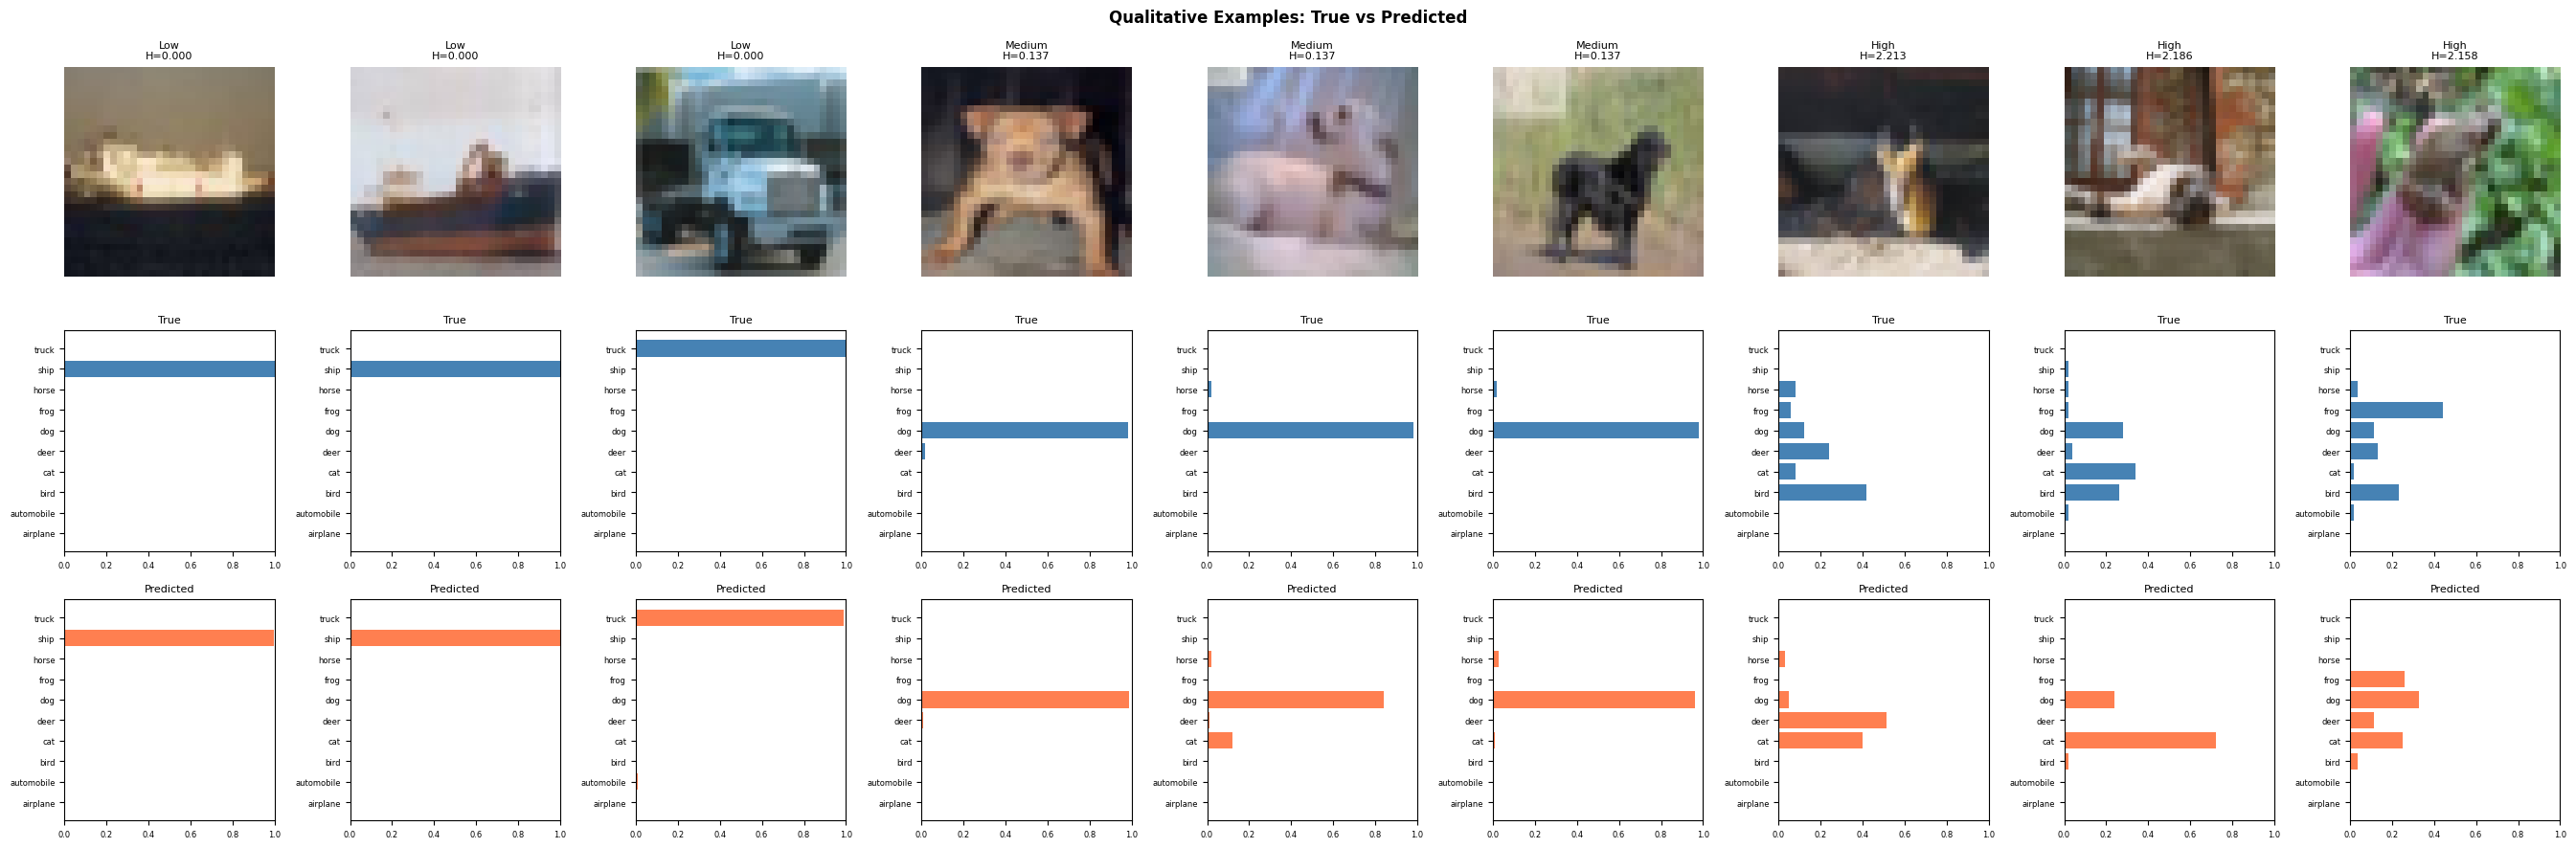

In [ ]:
# Qualitative examples: low / medium / high disagreement
best_preds = predictions['KL_Divergence']
s = np.argsort(true_entropy)
examples = np.concatenate([s[:3], s[len(s)//2-1:len(s)//2+2], s[-3:][::-1]])
cats = ['Low']*3 + ['Medium']*3 + ['High']*3

fig, axes = plt.subplots(3, 9, figsize=(27, 9))
for i, idx in enumerate(examples):
    orig = test_idx[idx]
    axes[0,i].imshow(np.array(cifar10_test[orig][0])); axes[0,i].axis('off')
    axes[0,i].set_title(f'{cats[i]}\nH={true_entropy[idx]:.3f}', fontsize=8)
    axes[1,i].barh(CIFAR10_CLASSES, true_soft[idx], color='steelblue'); axes[1,i].set_xlim(0,1)
    axes[1,i].set_title('True', fontsize=8); axes[1,i].tick_params(labelsize=6)
    axes[2,i].barh(CIFAR10_CLASSES, best_preds[idx], color='coral'); axes[2,i].set_xlim(0,1)
    axes[2,i].set_title('Predicted', fontsize=8); axes[2,i].tick_params(labelsize=6)
plt.suptitle('Qualitative Examples: True vs Predicted', fontweight='bold')
plt.tight_layout(); plt.savefig('viz_qualitative_examples.png', dpi=150); plt.show()

In [ ]:
# Ablation C: Training Data Strategy — train soft-only model
print('ABLATION C: Soft-only (random init) vs Pretrain+Finetune')
model_so = make_cifar_resnet18().to(device)
opt_so = optim.Adam(model_so.parameters(), lr=1e-4)
sched_so = optim.lr_scheduler.CosineAnnealingLR(opt_so, T_max=100)
kl_crit = KLDivergenceLoss()
best_vl, pat = float('inf'), 0

for epoch in range(100):
    tl = train_soft_label_epoch(model_so, soft_train_loader, kl_crit, opt_so, device)
    vl = eval_soft_label(model_so, soft_val_loader, kl_crit, device)
    sched_so.step()
    if vl < best_vl:
        best_vl, pat = vl, 0
        torch.save(model_so.state_dict(), os.path.join(SAVE_DIR, 'ablation_soft_only.pth'))
    else:
        pat += 1
    if (epoch+1) % 20 == 0: print(f'  Epoch {epoch+1} | Train: {tl:.6f} | Val: {vl:.6f}')
    if pat >= 10: print(f'  Early stopping at epoch {epoch+1}'); break

model_so.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'ablation_soft_only.pth'), map_location=device))
preds_so, _, _ = get_predictions(model_so, soft_test_loader, device)
preds_pt = predictions['KL_Divergence']

for label, p in [('Soft-only (random init)', preds_so), ('Pretrain+Finetune', preds_pt)]:
    kl = compute_kl_per_sample(true_soft, p).mean()
    cos = compute_cosine_per_sample(true_soft, p).mean()
    pr, _ = pearsonr(true_entropy, compute_entropy_np(p))
    print(f'{label}: KL={kl:.4f}, Cosine={cos:.4f}, Pearson={pr:.4f}')

ABLATION C: Soft-only (random init) vs Pretrain+Finetune
  Epoch 20 | Train: 0.661151 | Val: 1.092141
  Early stopping at epoch 34
Soft-only (random init): KL=1.1114, Cosine=0.6914, Pearson=0.1801
Pretrain+Finetune: KL=0.2732, Cosine=0.9338, Pearson=0.4532


ABLATION A: Random Init vs CIFAR-10 Pretrained


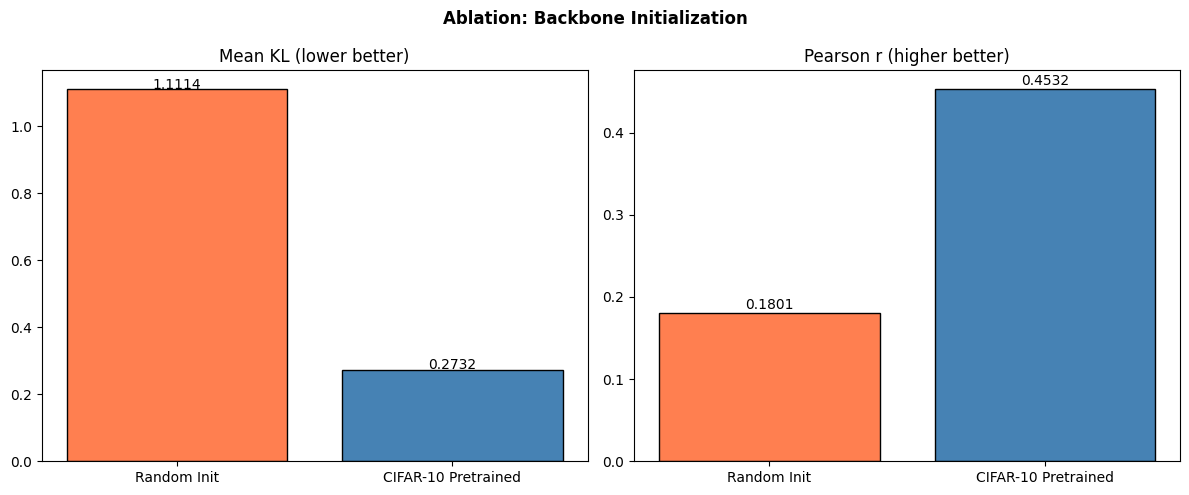

In [ ]:
# Ablation A: Backbone Initialization — chart
print('ABLATION A: Random Init vs CIFAR-10 Pretrained')
init_data = {}
for label, p in [('Random Init', preds_so), ('CIFAR-10 Pretrained', preds_pt)]:
    init_data[label] = {
        'KL': compute_kl_per_sample(true_soft, p).mean(),
        'Pearson': pearsonr(true_entropy, compute_entropy_np(p))[0]
    }

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
labels = list(init_data.keys())
kv = [init_data[l]['KL'] for l in labels]
pv = [init_data[l]['Pearson'] for l in labels]
ax1.bar(labels, kv, color=['coral','steelblue'], edgecolor='black'); ax1.set_title('Mean KL (lower better)')
for i,v in enumerate(kv): ax1.text(i, v+0.001, f'{v:.4f}', ha='center')
ax2.bar(labels, pv, color=['coral','steelblue'], edgecolor='black'); ax2.set_title('Pearson r (higher better)')
for i,v in enumerate(pv): ax2.text(i, v+0.005, f'{v:.4f}', ha='center')
plt.suptitle('Ablation: Backbone Initialization', fontweight='bold')
plt.tight_layout(); plt.savefig('viz_ablation_init.png', dpi=150); plt.show()

ROBUSTNESS C: Class-Conditional Performance
  airplane     KL: 0.3147  Cosine: 0.9283
  automobile   KL: 0.1442  Cosine: 0.9649
  bird         KL: 0.3149  Cosine: 0.9148
  cat          KL: 0.4503  Cosine: 0.8724
  deer         KL: 0.3493  Cosine: 0.9152
  dog          KL: 0.3313  Cosine: 0.9187
  frog         KL: 0.2300  Cosine: 0.9507
  horse        KL: 0.2090  Cosine: 0.9525
  ship         KL: 0.2329  Cosine: 0.9471
  truck        KL: 0.1500  Cosine: 0.9733


/tmp/ipykernel_408/252454802.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_title('Per-Class KL'); ax1.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha='right')
/tmp/ipykernel_408/252454802.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_title('Per-Class Cosine'); ax2.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha='right')


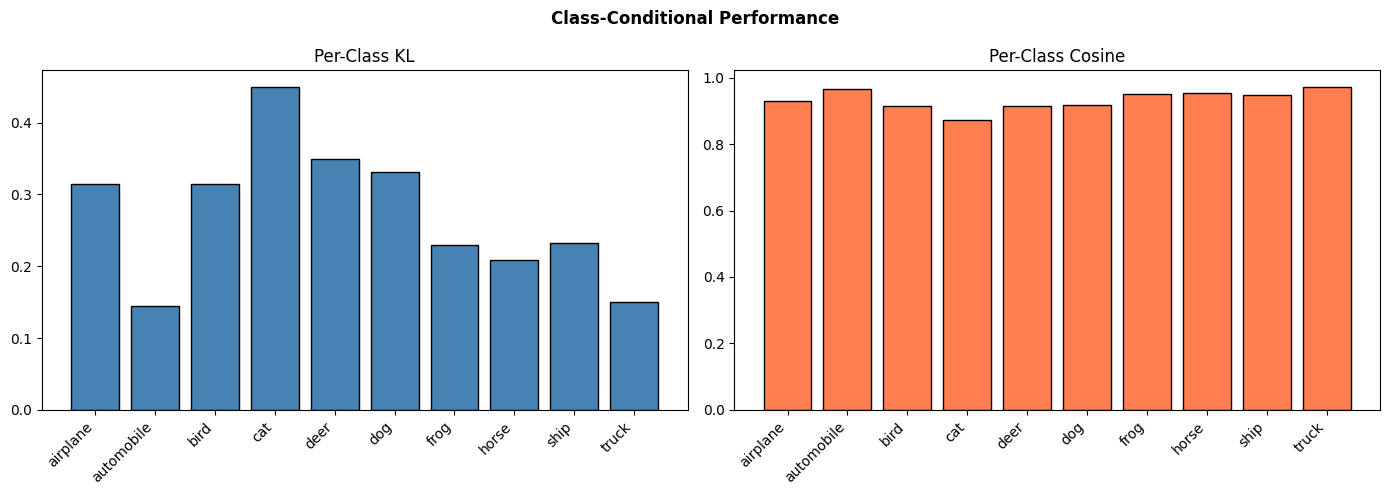

In [ ]:
# Robustness C: Class-conditional performance
print('ROBUSTNESS C: Class-Conditional Performance')
class_kl, class_cos = [], []
for c in range(10):
    mask = true_hard == c
    kl = compute_kl_per_sample(true_soft[mask], best_preds[mask]).mean()
    cos = compute_cosine_per_sample(true_soft[mask], best_preds[mask]).mean()
    class_kl.append(kl); class_cos.append(cos)
    print(f'  {CIFAR10_CLASSES[c]:<12} KL: {kl:.4f}  Cosine: {cos:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.bar(CIFAR10_CLASSES, class_kl, color='steelblue', edgecolor='black')
ax1.set_title('Per-Class KL'); ax1.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha='right')
ax2.bar(CIFAR10_CLASSES, class_cos, color='coral', edgecolor='black')
ax2.set_title('Per-Class Cosine'); ax2.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha='right')
plt.suptitle('Class-Conditional Performance', fontweight='bold')
plt.tight_layout(); plt.savefig('viz_class_performance.png', dpi=150); plt.show()

ROBUSTNESS B: OOD Corruptions
  Gaussian Noise severity 1...
  Gaussian Noise severity 2...
  Gaussian Noise severity 3...
  Gaussian Blur severity 1...
  Gaussian Blur severity 2...
  Gaussian Blur severity 3...
  Contrast Reduction severity 1...
  Contrast Reduction severity 2...
  Contrast Reduction severity 3...


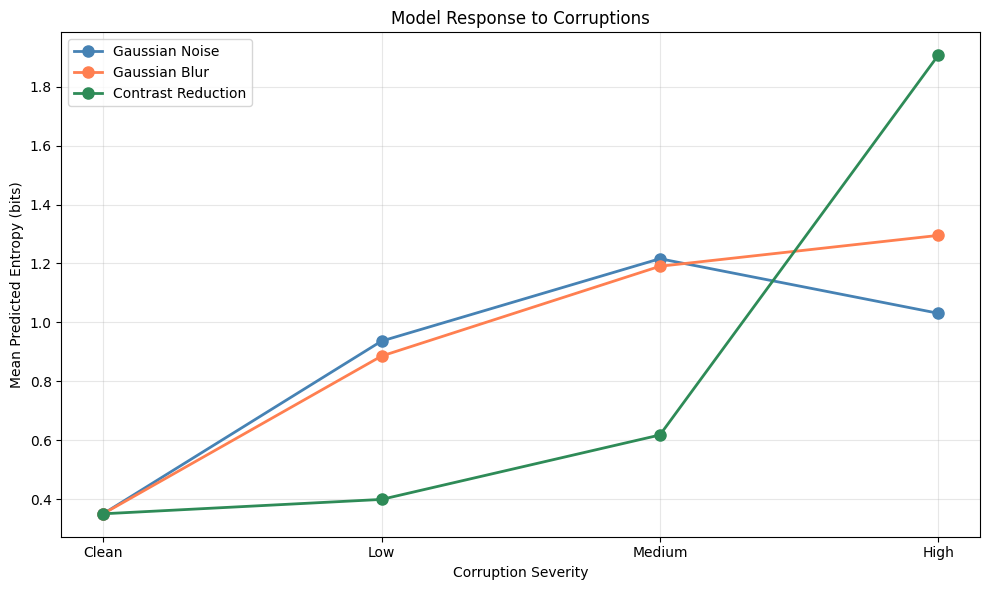

In [ ]:
# Robustness B: OOD Corruptions
print('ROBUSTNESS B: OOD Corruptions')
best_model = make_cifar_resnet18().to(device)
best_model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_KL_Divergence.pth'), map_location=device))
best_model.eval()

clean_ent = compute_entropy_np(best_preds).mean()
corr_fns = {'Gaussian Noise': gaussian_noise, 'Gaussian Blur': gaussian_blur, 'Contrast Reduction': contrast_reduction}
corr_results = {}

for cname, cfn in corr_fns.items():
    ents = [clean_ent]
    for sev in [1, 2, 3]:
        print(f'  {cname} severity {sev}...')
        p = predict_corrupted(best_model, cifar10_test, test_idx,
                              lambda img, s=sev, fn=cfn: fn(img, s), device)
        ents.append(compute_entropy_np(p).mean())
    corr_results[cname] = ents

fig, ax = plt.subplots(figsize=(10, 6))
cc = {'Gaussian Noise': 'steelblue', 'Gaussian Blur': 'coral', 'Contrast Reduction': 'seagreen'}
for cname, ents in corr_results.items():
    ax.plot([0,1,2,3], ents, 'o-', label=cname, color=cc[cname], linewidth=2, markersize=8)
ax.set_xticks([0,1,2,3]); ax.set_xticklabels(['Clean','Low','Medium','High'])
ax.set_xlabel('Corruption Severity'); ax.set_ylabel('Mean Predicted Entropy (bits)')
ax.set_title('Model Response to Corruptions'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('viz_corruption_response.png', dpi=150); plt.show()

In [ ]:
# Save results for Section 4
eval_results = {
    'predictions': predictions, 'true_soft': true_soft,
    'true_hard': true_hard, 'true_entropy': true_entropy,
}
with open(os.path.join(DATA_DIR, 'eval_results.pkl'), 'wb') as f:
    pickle.dump(eval_results, f)
print('Results saved.')

Results saved.


---
# Section 4: Explainability & Analysis

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


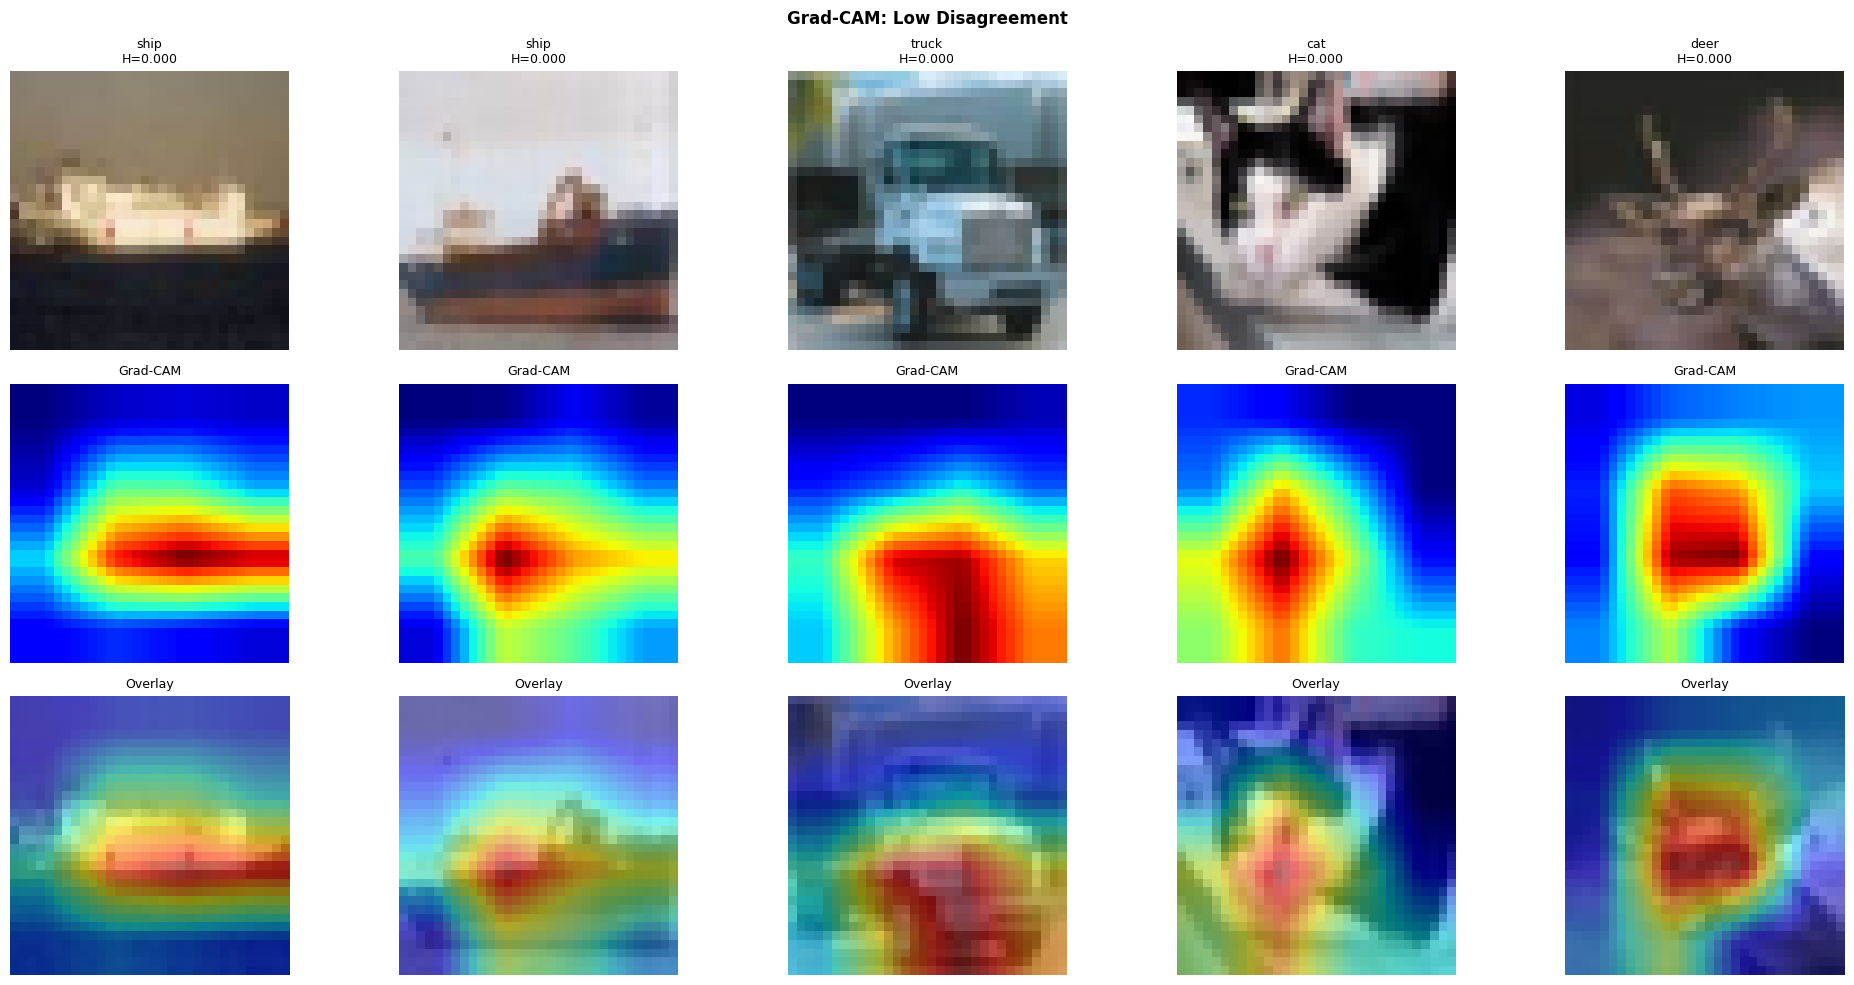

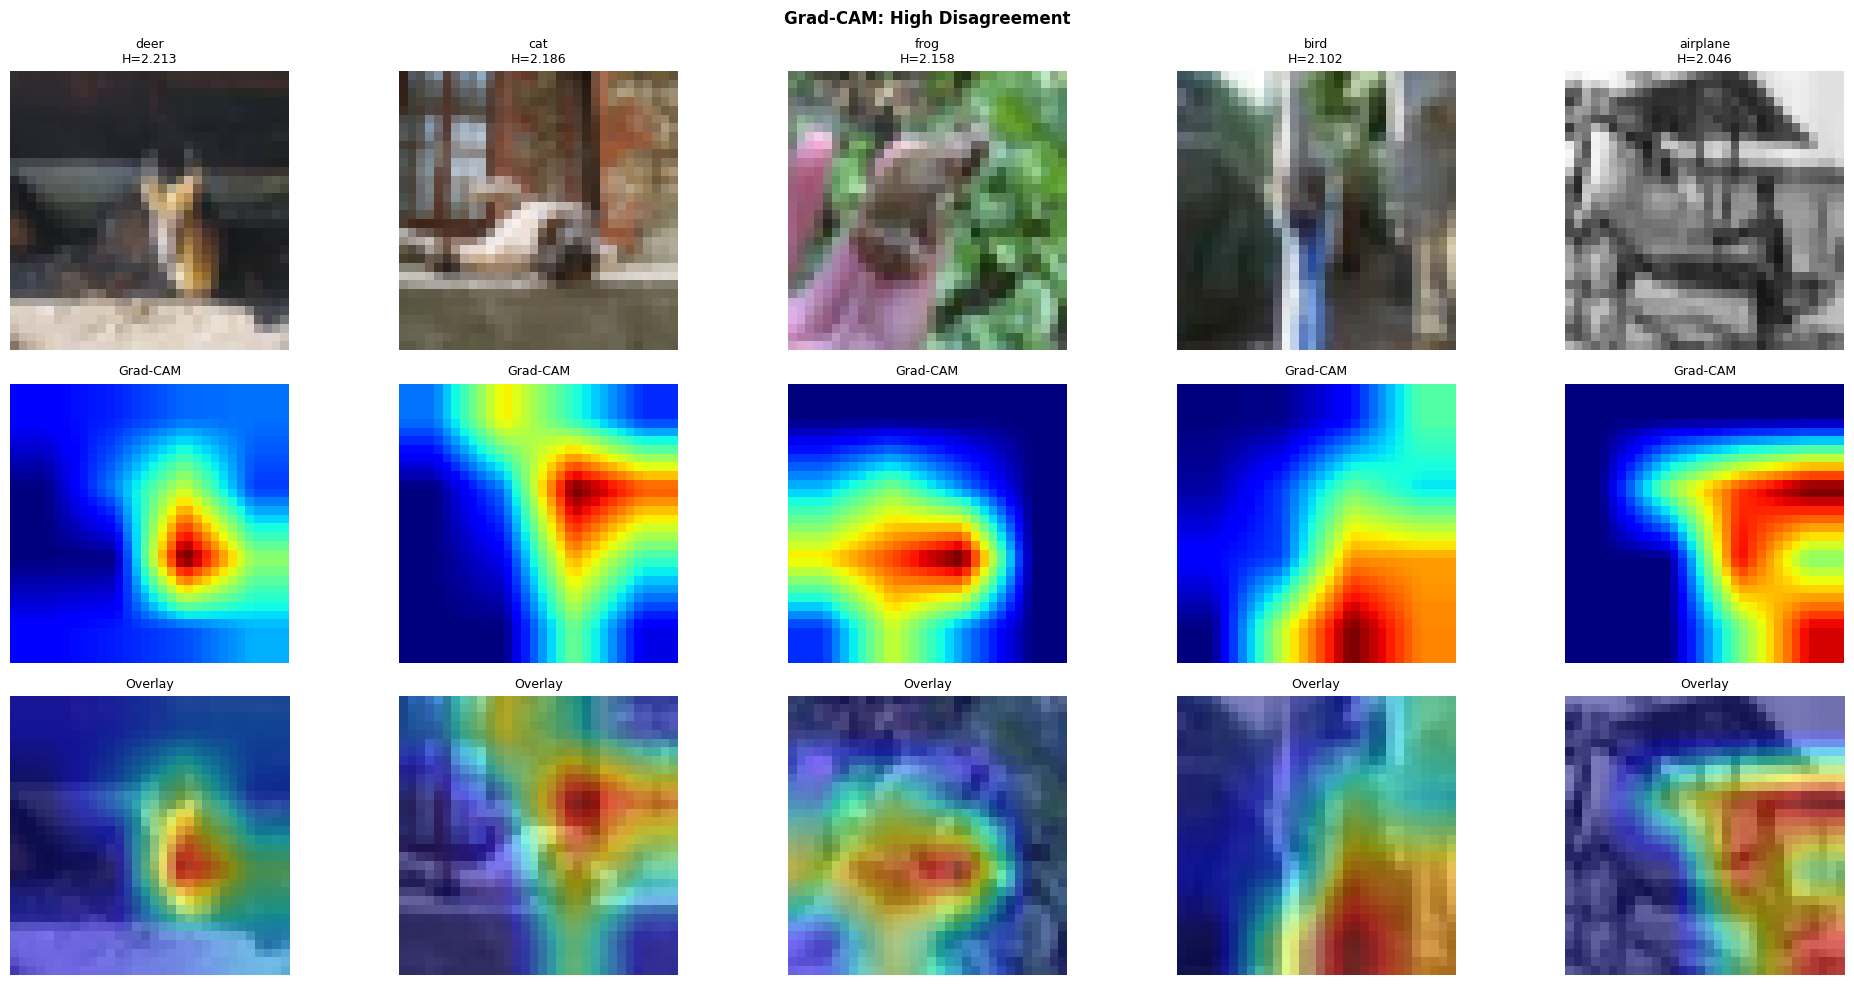

In [ ]:
# Grad-CAM
grad_cam = GradCAM(best_model, best_model.layer4[-1])
sorted_te = np.argsort(true_entropy)
pred_entropy = compute_entropy_np(best_preds)

def plot_gradcam(indices, title, filename):
    n = len(indices)
    fig, axes = plt.subplots(3, n, figsize=(4*n, 10))
    for i, ti in enumerate(indices):
        orig = test_idx[ti]
        img_pil, _ = cifar10_test[orig]
        img_np = np.array(img_pil)
        inp = normalize(to_tensor(img_pil)).unsqueeze(0).to(device)
        inp.requires_grad_(True)
        heatmap = grad_cam.generate(inp)

        axes[0,i].imshow(img_np); axes[0,i].axis('off')
        axes[0,i].set_title(f'{CIFAR10_CLASSES[true_hard[ti]]}\nH={true_entropy[ti]:.3f}', fontsize=9)
        axes[1,i].imshow(heatmap, cmap='jet'); axes[1,i].axis('off'); axes[1,i].set_title('Grad-CAM', fontsize=9)
        overlay = np.clip(0.5*img_np.astype(np.float32)/255 + 0.5*cm.jet(heatmap)[:,:,:3], 0, 1)
        axes[2,i].imshow(overlay); axes[2,i].axis('off'); axes[2,i].set_title('Overlay', fontsize=9)
    fig.suptitle(title, fontweight='bold'); plt.tight_layout()
    plt.savefig(filename, dpi=150); plt.show()

plot_gradcam(sorted_te[:5], 'Grad-CAM: Low Disagreement', 'viz_gradcam_low.png')
plot_gradcam(sorted_te[-5:][::-1], 'Grad-CAM: High Disagreement', 'viz_gradcam_high.png')

### Grad-CAM Discussion




In [ ]:
# Failure case analysis
kl_per = compute_kl_per_sample(true_soft, best_preds)
worst = np.argsort(kl_per)[-10:][::-1]

print('Top 10 Failure Cases:')
for rank, ti in enumerate(worst, 1):
    t3 = np.argsort(true_soft[ti])[-3:][::-1]
    p3 = np.argsort(best_preds[ti])[-3:][::-1]
    print(f'#{rank} | {CIFAR10_CLASSES[true_hard[ti]]} | KL={kl_per[ti]:.4f} | '
          f'True H={true_entropy[ti]:.3f} Pred H={pred_entropy[ti]:.3f}')
    print(f'  True:  {[(CIFAR10_CLASSES[c], f"{true_soft[ti][c]:.3f}") for c in t3]}')
    print(f'  Pred:  {[(CIFAR10_CLASSES[c], f"{best_preds[ti][c]:.3f}") for c in p3]}')

Top 10 Failure Cases:
#1 | dog | KL=6.6382 | True H=0.278 Pred H=0.196
  True:  [('dog', '0.961'), ('horse', '0.020'), ('frog', '0.020')]
  Pred:  [('airplane', '0.977'), ('horse', '0.012'), ('truck', '0.006')]
#2 | horse | KL=5.7075 | True H=0.278 Pred H=1.474
  True:  [('horse', '0.961'), ('deer', '0.020'), ('automobile', '0.020')]
  Pred:  [('ship', '0.549'), ('airplane', '0.351'), ('automobile', '0.074')]
#3 | bird | KL=5.6511 | True H=0.137 Pred H=1.055
  True:  [('bird', '0.981'), ('deer', '0.019'), ('ship', '0.000')]
  Pred:  [('deer', '0.825'), ('horse', '0.063'), ('airplane', '0.044')]
#4 | ship | KL=5.3702 | True H=0.141 Pred H=0.098
  True:  [('ship', '0.980'), ('airplane', '0.020'), ('truck', '0.000')]
  Pred:  [('automobile', '0.990'), ('ship', '0.004'), ('truck', '0.003')]
#5 | frog | KL=5.0999 | True H=0.000 Pred H=0.082
  True:  [('frog', '1.000'), ('truck', '0.000'), ('ship', '0.000')]
  Pred:  [('bird', '0.992'), ('frog', '0.006'), ('deer', '0.001')]
#6 | dog | KL=4.8

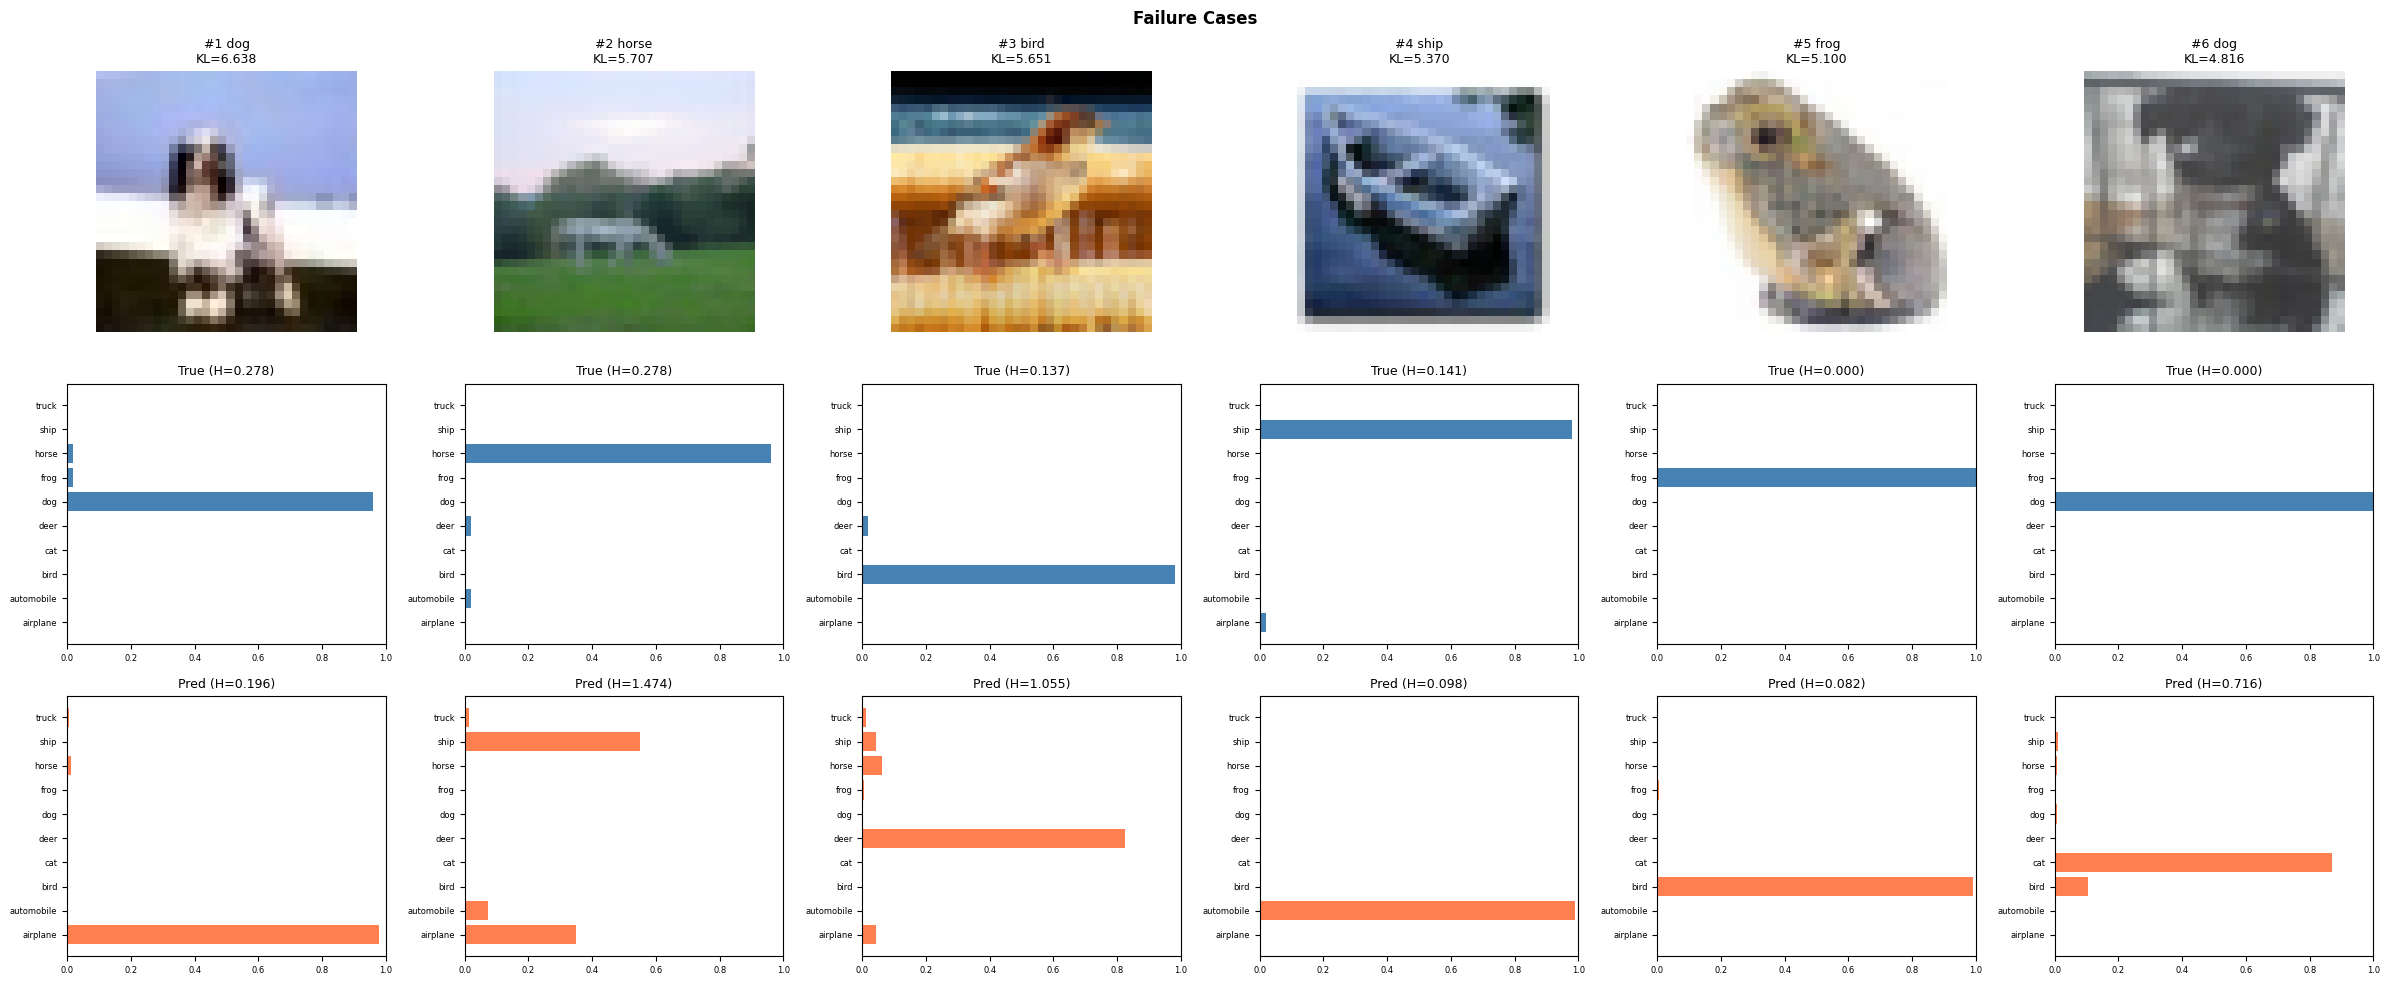

In [ ]:
# Failure case visualization
n_show = 6
fig, axes = plt.subplots(3, n_show, figsize=(4*n_show, 10))
for i in range(n_show):
    ti = worst[i]; orig = test_idx[ti]
    axes[0,i].imshow(np.array(cifar10_test[orig][0])); axes[0,i].axis('off')
    axes[0,i].set_title(f'#{i+1} {CIFAR10_CLASSES[true_hard[ti]]}\nKL={kl_per[ti]:.3f}', fontsize=9)
    axes[1,i].barh(CIFAR10_CLASSES, true_soft[ti], color='steelblue'); axes[1,i].set_xlim(0,1)
    axes[1,i].set_title(f'True (H={true_entropy[ti]:.3f})', fontsize=9); axes[1,i].tick_params(labelsize=6)
    axes[2,i].barh(CIFAR10_CLASSES, best_preds[ti], color='coral'); axes[2,i].set_xlim(0,1)
    axes[2,i].set_title(f'Pred (H={pred_entropy[ti]:.3f})', fontsize=9); axes[2,i].tick_params(labelsize=6)
plt.suptitle('Failure Cases', fontweight='bold')
plt.tight_layout(); plt.savefig('viz_failure_cases.png', dpi=150); plt.show()

### Failure Case Hypotheses



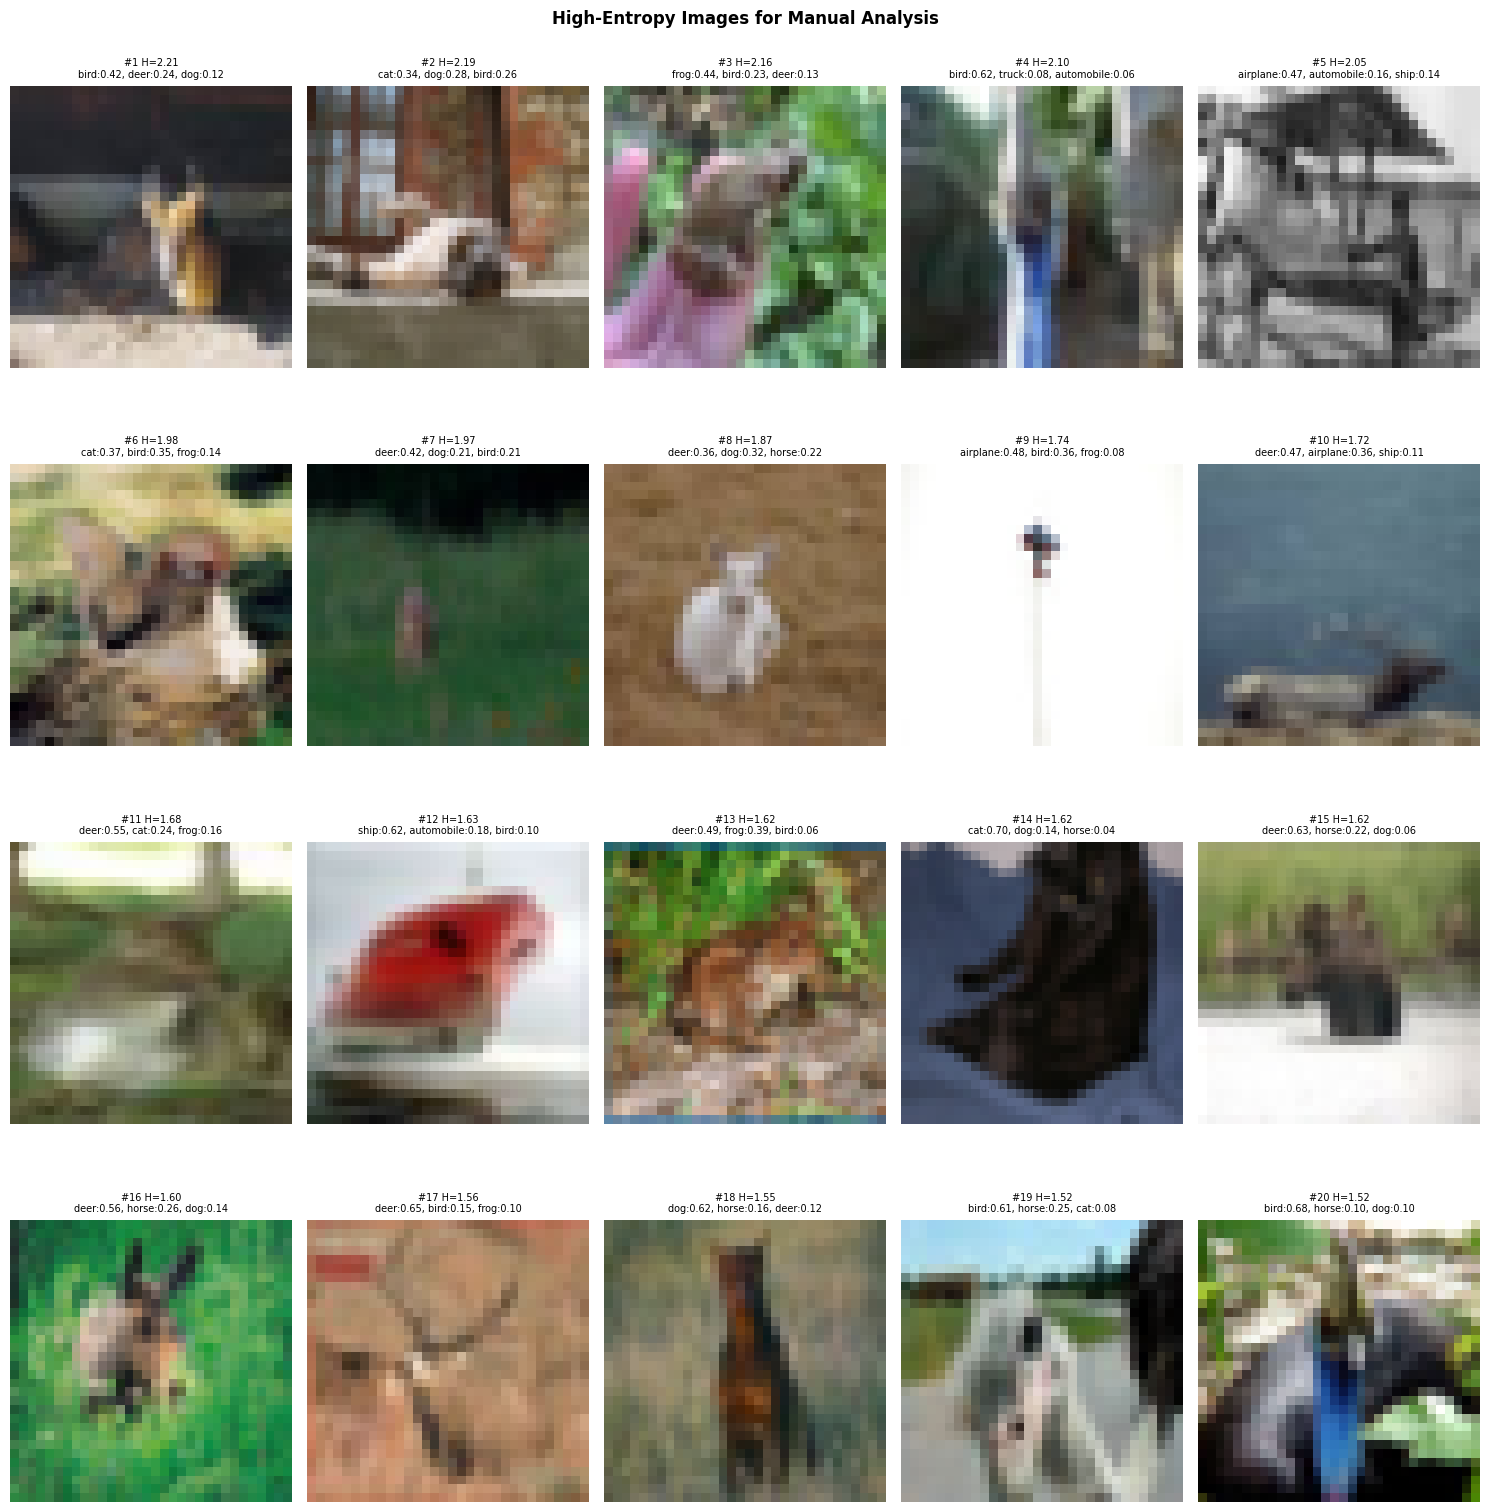

In [ ]:
# Manual disagreement source analysis — display 20 high-entropy images
manual_idx = sorted_te[-20:][::-1]
fig, axes = plt.subplots(4, 5, figsize=(15, 16))
for i, ti in enumerate(manual_idx):
    ax = axes[i//5, i%5]; orig = test_idx[ti]
    ax.imshow(np.array(cifar10_test[orig][0]))
    t3 = np.argsort(true_soft[ti])[-3:][::-1]
    t3s = ', '.join(f'{CIFAR10_CLASSES[c]}:{true_soft[ti][c]:.2f}' for c in t3)
    ax.set_title(f'#{i+1} H={true_entropy[ti]:.2f}\n{t3s}', fontsize=7); ax.axis('off')
plt.suptitle('High-Entropy Images for Manual Analysis', fontweight='bold')
plt.tight_layout(); plt.savefig('viz_manual_analysis.png', dpi=150); plt.show()